In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

#TODO consider making a parent class and then this a subclass specifically for svd. This would make it easier to add other compression methods later.
class CompressedPointwiseConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, rank=None, bias=True):
        super().__init__()

        # Conv 1D attributes
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.bias_flag = bias
    
        # Full weight initialization via a temporary conv layer (kaiming uniform init) 
        conv_init = nn.Conv1d(self.in_channels, self.out_channels, kernel_size=1, bias=self.bias_flag)
        self.weight_full = nn.Parameter(conv_init.weight.data.clone())
        self.bias = nn.Parameter(conv_init.bias.data.clone()) if self.bias_flag else None # type: ignore
        del conv_init  # free memory

        # Low-rank attributes
        self.rank = rank  # None = full rank
        self.U = None
        self.V = None
        self.S = None

    def activate_low_rank(self, rank: int):
        """Compute SVD from full weight and keep top-`rank` components."""
        W = self.weight_full.detach().squeeze(-1)  # [out, in]
        U, S, Vt = torch.linalg.svd(W, full_matrices=False)

        self.rank = rank
        self.U = nn.Parameter(U[:, :rank].clone())
        self.S = nn.Parameter(S[:rank].clone())
        self.V = nn.Parameter(Vt[:rank, :].clone())

    def deactivate_low_rank(self):
        """Disable low-rank mode and use full weights."""
        self.rank = None
        self.U = self.S = self.V = None

    # --- forward ---
    def forward(self, x):
        if self.rank is None:
            return F.conv1d(x, self.weight_full, self.bias)
        else:
            W_approx = (self.U @ torch.diag(self.S) @ self.V).unsqueeze(-1) # type: ignore
            return F.conv1d(x, W_approx, self.bias)

X_in shape: torch.Size([200, 20, 10]), Y_in shape: torch.Size([200, 10, 10])
Y_pred shape: torch.Size([200, 10, 10])
Y_in shape: torch.Size([200, 10, 10])
MSE (full-rank sanity check): 0.009936
Full-rank MSE: 0.009936
Rank  1 → MSE 15.253887
Rank  2 → MSE 11.137156
Rank  3 → MSE 8.162444
Rank  4 → MSE 5.236954
Rank  5 → MSE 3.250781
Rank  6 → MSE 1.895253
Rank  7 → MSE 0.931613
Rank  8 → MSE 0.440989
Rank  9 → MSE 0.129290
Rank 10 → MSE 0.009936


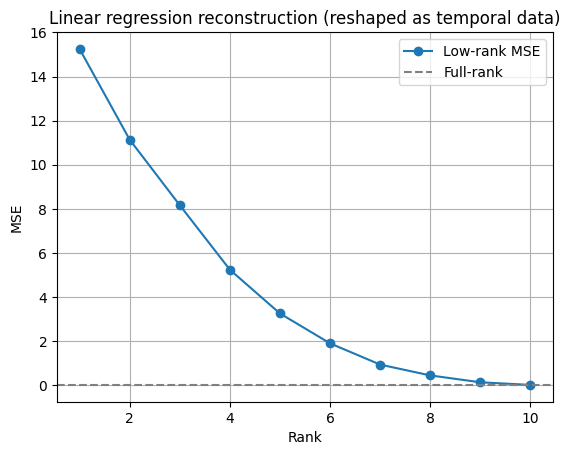

In [6]:
import matplotlib.pyplot as plt
# --- Generate data (no time dimension) ---
torch.manual_seed(0)
n, d, m = 2000, 20, 10
X = torch.randn(n, d)
true_W = torch.randn(d, m)
Y = X @ true_W + 0.1 * torch.randn(n, m)

# closed-form regression solution
W_opt = torch.linalg.inv(X.T @ X) @ X.T @ Y  # [d, m]

# --- Reshape into temporal form ---
T = 10                     # number of "time steps" per sample
batch_size = n // T        # 200
X_time = X.view(batch_size, T, d)    # [B, T, d]
Y_time = Y.view(batch_size, T, m)    # [B, T, m]

# Conv1d expects [B, in_channels, length]
X_in = X_time.transpose(1, 2).contiguous()  # [B, d, T]
Y_in = Y_time.transpose(1, 2).contiguous()  # [B, m, T]

print(f"X_in shape: {X_in.shape}, Y_in shape: {Y_in.shape}")
# -> [200, 20, 10], [200, 5, 10]

# --- Model setup ---
model = CompressedPointwiseConv1d(in_channels=d, out_channels=m, bias=False)
model.weight_full.data = W_opt.T.unsqueeze(-1).clone()  # [m, d, 1]

# quick sanity check
with torch.no_grad():
    Y_pred = model(X_in)
print("Y_pred shape:", Y_pred.shape)  # [batch, m, T]
print("Y_in shape:", Y_in.shape)

# --- Verify that flattening matches analytic result ---
Y_flat = Y_in.transpose(1, 2).reshape(-1, m)      # [n, m]
Y_pred_flat = Y_pred.transpose(1, 2).reshape(-1, m)
mse_check = F.mse_loss(Y_pred_flat, Y)
print(f"MSE (full-rank sanity check): {mse_check:.6f}")

# --- 5️⃣ Test low-rank compression ---
def mse_for_rank(rank):
    model.activate_low_rank(rank)
    with torch.no_grad():
        Y_pred = model(X_in)
        mse = F.mse_loss(Y_pred, Y_in)
    return mse.item()

ranks = list(range(1, m + 1))
errors = [mse_for_rank(r) for r in ranks]

# full-rank baseline
model.deactivate_low_rank()
with torch.no_grad():
    mse_full = F.mse_loss(model(X_in), Y_in).item()

print(f"Full-rank MSE: {mse_full:.6f}")
for r, e in zip(ranks, errors):
    print(f"Rank {r:2d} → MSE {e:.6f}")

plt.plot(ranks, errors, "o-", label="Low-rank MSE")
plt.axhline(mse_full, color="gray", linestyle="--", label="Full-rank")
plt.xlabel("Rank")
plt.ylabel("MSE")
plt.title("Linear regression reconstruction (reshaped as temporal data)")
plt.grid(True)
plt.legend()
plt.show()

In [7]:
N_FFT = 1024
HOP_LENGTH = 256
DDWS_CHANNELS_EXT = 128
DDWS_CHANNELS_INT = 128
FRONTEND_IN_CHANNELS = N_FFT // 2 + 1
FRONTEND_OUT_CHANNELS = DDWS_CHANNELS_EXT
BACKEND_IN_CHANNELS = DDWS_CHANNELS_EXT
BACKEND_OUT_CHANNELS = 35 # number of classes
NUM_BLOCKS_PR_STACK = 3
NUM_STACKS = 1
DILATION_BASE = 2


class keyword_spotting(torch.nn.Module):
    #TODO: make this more modular, by adding more flexibiility, and not hardcoding parameters
    def __init__():
        super().__init__()
        
       
    
    def forward(self, x):
        x = self.spectrogram(x)
        return x